In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, DenseNet121
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [21]:
augmented_dir = "/kaggle/input/datasets/marjukibnabelayet/cse438-group4/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Augmented_Dataset"

original_dir = "/kaggle/input/datasets/marjukibnabelayet/cse438-group4/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset"

In [22]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_STAGE1 = 10
EPOCHS_STAGE2 = 20
SEED = 42

AUTOTUNE = tf.data.AUTOTUNE
tf.keras.utils.set_random_seed(SEED)

In [23]:
class_names = sorted([
    d for d in os.listdir(augmented_dir)
    if os.path.isdir(os.path.join(augmented_dir, d))
])

num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['Healthy_Leaf', 'Leaf_Rot', 'Leaf_Spot']
Number of classes: 3


In [24]:
def get_image_paths_and_labels(data_dir, class_names):
    file_paths = []
    labels = []

    valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    for idx, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):
            if file_name.lower().endswith(valid_ext):
                file_paths.append(os.path.join(class_path, file_name))
                labels.append(idx)

    return file_paths, labels

In [25]:
train_paths, train_labels = get_image_paths_and_labels(augmented_dir, class_names)
original_paths, original_labels = get_image_paths_and_labels(original_dir, class_names)

print("Training images from Augmented_Dataset:", len(train_paths))
print("Images from Original_Dataset:", len(original_paths))

Training images from Augmented_Dataset: 10185
Images from Original_Dataset: 2037


In [26]:
val_paths, test_paths, val_labels, test_labels = train_test_split(
    original_paths,
    original_labels,
    test_size=0.5,
    random_state=SEED,
    stratify=original_labels
)

print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))

Validation images: 1018
Test images: 1019


In [27]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = {i: w for i, w in enumerate(class_weights_array)}
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.6287037037037037), 1: np.float64(2.524163568773234), 2: np.float64(0.9869186046511628)}


In [28]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.12),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
    layers.RandomTranslation(0.08, 0.08),
], name="data_augmentation")

In [29]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

In [30]:
def augment_image(image, label):
    image = data_augmentation(image, training=True)
    return image, label

In [31]:
def create_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment_image, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

In [32]:
train_ds = create_dataset(train_paths, train_labels, training=True)
val_ds = create_dataset(val_paths, val_labels, training=False)
test_ds = create_dataset(test_paths, test_labels, training=False)

print("Datasets created successfully.")

Datasets created successfully.


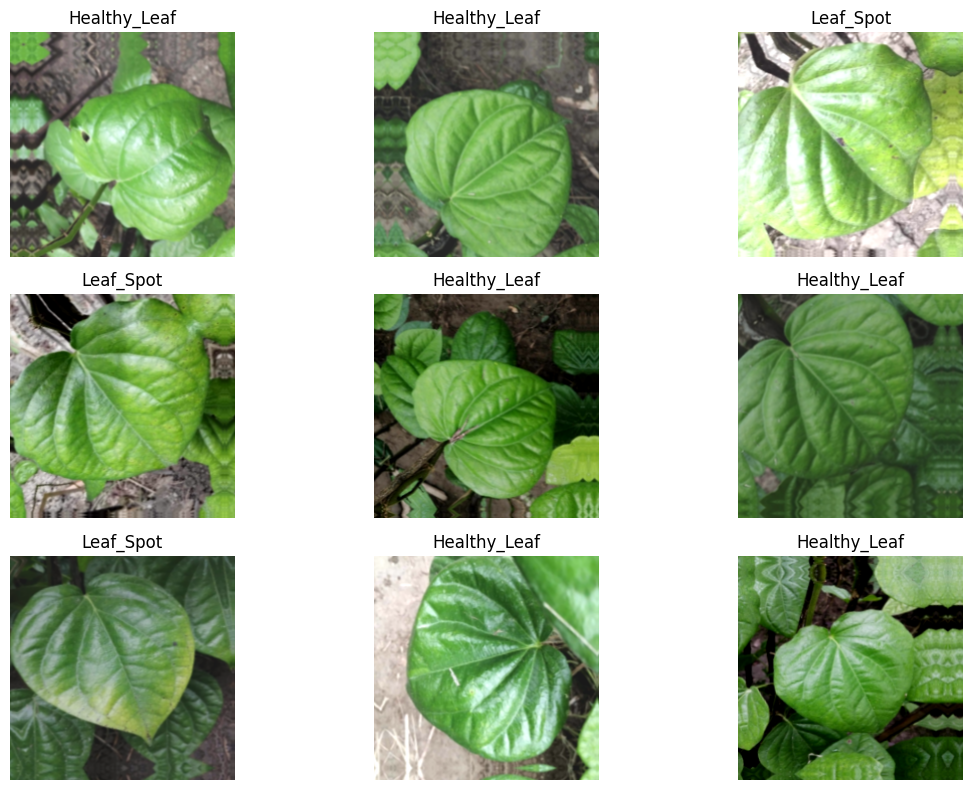

In [33]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [34]:
input_layer = layers.Input(shape=(224, 224, 3), name="input_image")

In [35]:
x1 = layers.Lambda(resnet_preprocess, name="resnet_preprocess")(input_layer)

resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

resnet_base.trainable = False

x1 = resnet_base(x1, training=False)
x1 = layers.GlobalAveragePooling2D()(x1)
x1 = layers.BatchNormalization()(x1)
x1 = layers.Dense(256, activation="relu", kernel_regularizer=l2(1e-4))(x1)
x1 = layers.Dropout(0.30)(x1)

In [36]:
x2 = layers.Lambda(densenet_preprocess, name="densenet_preprocess")(input_layer)

densenet_base = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

densenet_base.trainable = False

x2 = densenet_base(x2, training=False)
x2 = layers.GlobalAveragePooling2D()(x2)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Dense(256, activation="relu", kernel_regularizer=l2(1e-4))(x2)
x2 = layers.Dropout(0.30)(x2)

In [37]:
fusion = layers.Concatenate(name="late_fusion_concat")([x1, x2])
fusion = layers.BatchNormalization()(fusion)
fusion = layers.Dense(512, activation="relu", kernel_regularizer=l2(1e-4))(fusion)
fusion = layers.Dropout(0.35)(fusion)
fusion = layers.Dense(256, activation="relu", kernel_regularizer=l2(1e-4))(fusion)
fusion = layers.Dropout(0.25)(fusion)
fusion = layers.Dense(128, activation="relu", kernel_regularizer=l2(1e-4))(fusion)

In [38]:
output_layer = layers.Dense(num_classes, activation="softmax", name="output")(fusion)

model = Model(
    inputs=input_layer,
    outputs=output_layer,
    name="LateFusion_ResNet50_DenseNet121_Finetuned"
)

model.summary()

Model: "LateFusion_ResNet50_DenseNet121_Finetuned"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet_preprocess   │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet_preprocess │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ resnet_preproces… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 7, 7,      │  7,037,504 │ densenet_preproc… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    524,544 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    262,400 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ late_fusion_concat  │ (None, 512)       │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ late_fusion_conc… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 512)       │    262,656 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 512)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │    131,328 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 31,853,763 (121.51 MB)

 Trainable params: 1,221,379 (4.66 MB)

 Non-trainable params: 30,632,384 (116.85 MB)

In [39]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [40]:
callbacks_stage1 = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        verbose=1,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        "pipeline7_stage1_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

In [41]:
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    class_weight=class_weights,
    callbacks=callbacks_stage1
)

Epoch 1/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.5439 - loss: 1.1277
Epoch 1: val_accuracy improved from -inf to 0.85167, saving model to pipeline7_stage1_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 207s 531ms/step - accuracy: 0.5443 - loss: 1.1271 - val_accuracy: 0.8517 - val_loss: 0.6177 - learning_rate: 1.0000e-04
Epoch 2/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.7986 - loss: 0.7212
Epoch 2: val_accuracy improved from 0.85167 to 0.90472, saving model to pipeline7_stage1_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 128s 399ms/step - accuracy: 0.7986 - loss: 0.7211 - val_accuracy: 0.9047 - val_loss: 0.4630 - learning_rate: 1.0000e-04
Epoch 3/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.8314 - loss: 0.6423
Epoch 3: val_accuracy improved from 0.90472 to 0.90864, saving model to pipeline7_stage1_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 126s 395ms/step - accuracy: 0.8314 - loss: 0.6422 - val_accuracy: 0.9086 - val_loss: 0.4288 - learning_rate: 1.0

In [42]:
resnet_base.trainable = True
densenet_base.trainable = True

for layer in resnet_base.layers[:-50]:
    layer.trainable = False

for layer in densenet_base.layers[:-50]:
    layer.trainable = False

In [43]:
for layer in resnet_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

for layer in densenet_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

In [44]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [45]:
callbacks_stage2 = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        verbose=1,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        "late_fusion_pipeline7_best_finetuned.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
]

In [46]:
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    class_weight=class_weights,
    callbacks=callbacks_stage2
)

Epoch 1/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.9055 - loss: 0.4232
Epoch 1: val_accuracy improved from -inf to 0.94794, saving model to late_fusion_pipeline7_best_finetuned.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 239s 597ms/step - accuracy: 0.9055 - loss: 0.4232 - val_accuracy: 0.9479 - val_loss: 0.3076 - learning_rate: 1.0000e-05
Epoch 2/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.9116 - loss: 0.4000
Epoch 2: val_accuracy improved from 0.94794 to 0.95972, saving model to late_fusion_pipeline7_best_finetuned.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 146s 457ms/step - accuracy: 0.9116 - loss: 0.4000 - val_accuracy: 0.9597 - val_loss: 0.2958 - learning_rate: 1.0000e-05
Epoch 3/20
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.9216 - loss: 0.3851
Epoch 3: val_accuracy did not improve from 0.95972
319/319 ━━━━━━━━━━━━━━━━━━━━ 143s 447ms/step - accuracy: 0.9217 - loss: 0.3850 - val_accuracy: 0.9509 - val_loss: 0.2960 - learning_rate: 1.0000e-05
Epoch 4/20


In [47]:
history = {}
for key in history_stage1.history.keys():
    history[key] = history_stage1.history[key] + history_stage2.history[key]

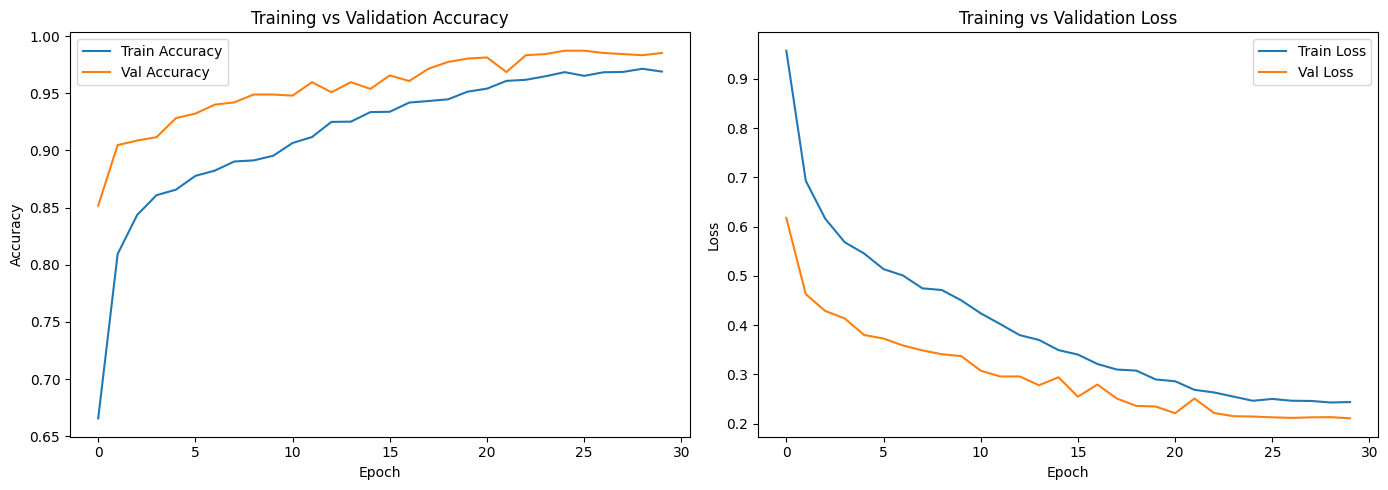

In [48]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history["accuracy"], label="Train Accuracy")
plt.plot(history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [52]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

best_model = tf.keras.models.load_model(
    "late_fusion_pipeline7_best_finetuned.keras",
    compile=False,
    custom_objects={
        "preprocess_input": resnet_preprocess,
        "resnet_preprocess": resnet_preprocess,
        "densenet_preprocess": densenet_preprocess
    }
)

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [53]:
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 565ms/step - accuracy: 0.6249 - loss: 14.9206
Test Loss: 15.379877090454102
Test Accuracy: 0.6064769625663757


In [54]:
y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)
y_pred_probs = best_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 783ms/step
              precision    recall  f1-score   support

Healthy_Leaf       0.65      0.98      0.78       540
    Leaf_Rot       0.43      0.65      0.51       135
   Leaf_Spot       0.00      0.00      0.00       344

    accuracy                           0.61      1019
   macro avg       0.36      0.54      0.43      1019
weighted avg       0.40      0.61      0.48      1019



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


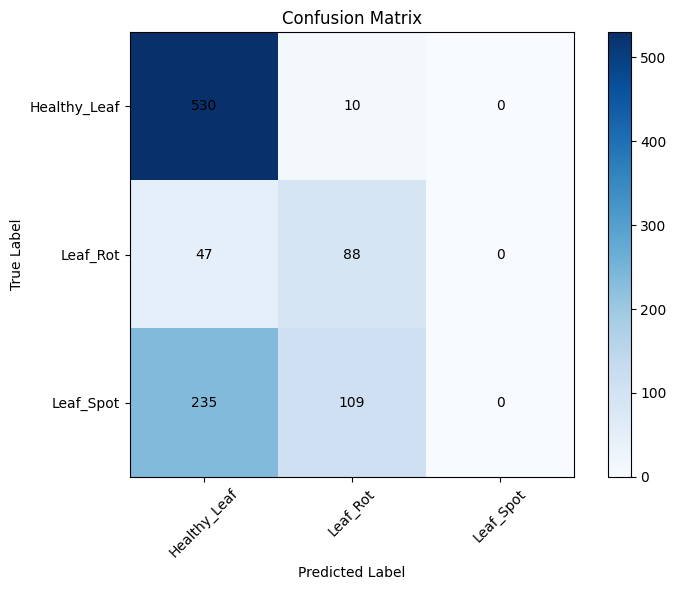

In [55]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [56]:
best_model.save("late_fusion_pipeline7_final_finetuned.keras")
print("Model saved successfully.")

Model saved successfully.
